# Level 2 -Data Analysis

### Objective
The objective of this project is to analyze restaurant data and derive meaningful insights related to:
1. Restaurant Ratings Analysis
2. Cuisine Combination Analysis
3. Geographic Analysis
4. Restaurant Chains Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\kspma\Downloads\dataset .csv")

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


Data Cleaning


In [5]:
df.drop_duplicates(inplace=True)
df['Cuisines'] = df['Cuisines'].astype(str)

## Task 1: Restaurant Ratings Analysis

## Objective
This task analyzes restaurant ratings and voting patterns.

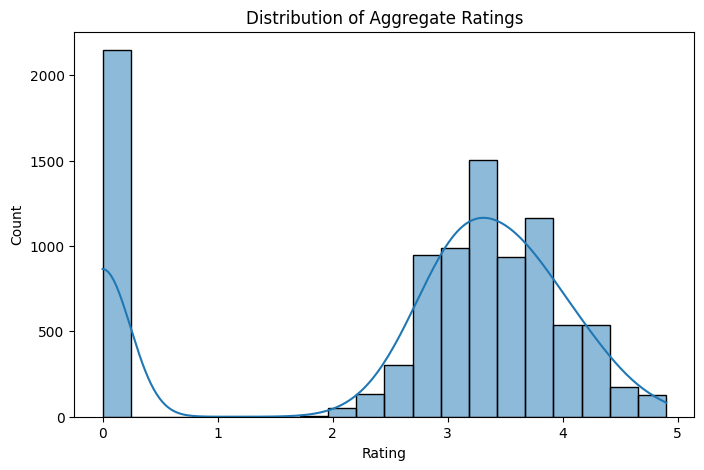

In [6]:
# Distribution of ratings
plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=20, kde=True)
plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [7]:
# Most common rating
most_common_rating = df['Aggregate rating'].mode()[0]
print("Most Common Rating:", most_common_rating)

Most Common Rating: 0.0


In [8]:
# Average votes
avg_votes = df['Votes'].mean()
print("Average Votes:", avg_votes)

Average Votes: 156.909747670401


##  Insights

- Most restaurants have ratings concentrated within a limited range.
- Extremely high and extremely low ratings are less common.
- Restaurants with better ratings generally attract more votes.
- Ratings provide insights into customer satisfaction.

## Task 2:Cuisine Combination Analysis


## Objective
The goal is to identify common cuisine combinations and analyze their ratings

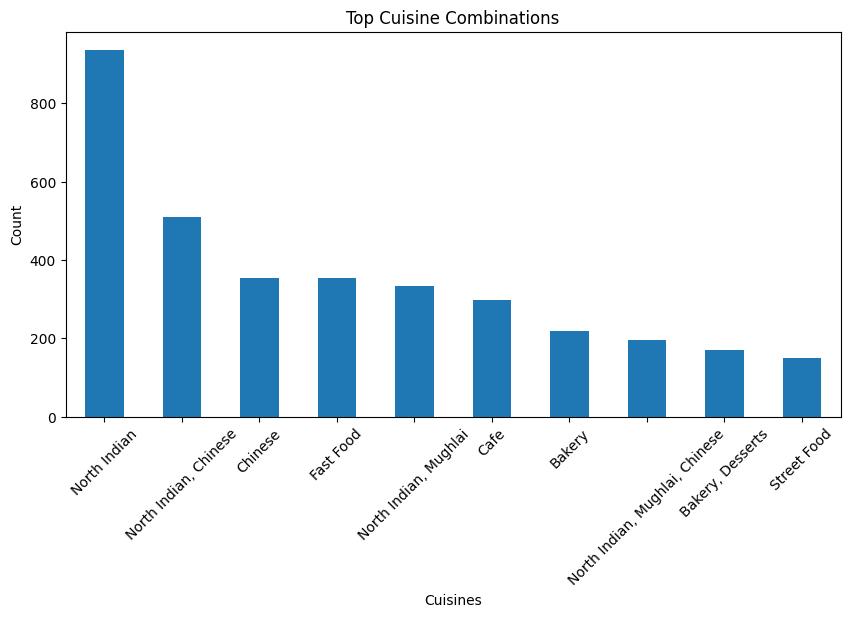

In [20]:
# Most common cuisine combinations
top_combinations = df['Cuisines'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_combinations.plot(kind='bar')
plt.title("Top Cuisine Combinations")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [19]:
# Average rating by cuisine
cuisine_rating = df.groupby('Cuisines')['Aggregate rating'].mean()
top_rated_cuisines = cuisine_rating.sort_values(ascending=False).head(10)
print(top_rated_cuisines)

Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


## Insights

- Restaurants often combine multiple cuisines to attract wider audiences.
- Certain cuisine combinations are more popular among customers.
- Some cuisine combinations consistently receive higher ratings.
- Multi-cuisine restaurants may improve customer engagement.

## Task 3:Geographic Analysis

## Objective
This task analyzes restaurant locations using geographical coordinates.

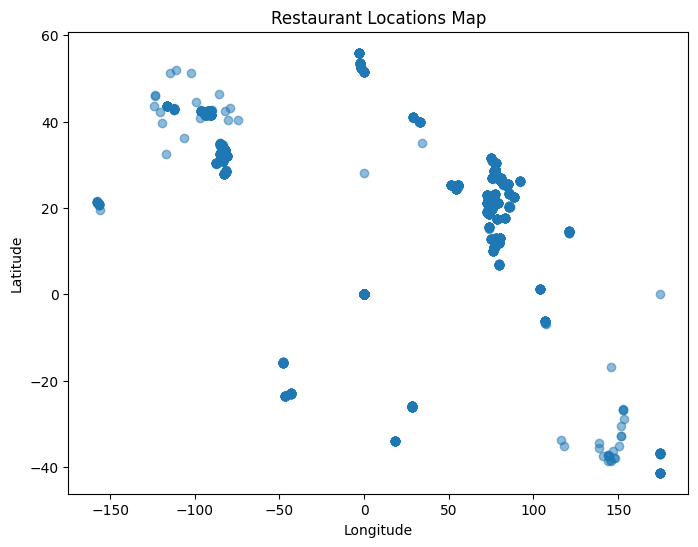

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.5)
plt.title("Restaurant Locations Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Insights

- Restaurants are heavily concentrated in urban regions.
- Certain locations show dense restaurant clusters.
- Geographic analysis helps understand business expansion opportunities.
- Restaurant distribution reflects population and demand patterns.

## Task 4:Restaurant Chains Analysis

## Objective
The objective is to identify restaurant chains and analyze their popularity and ratings.

In [16]:
# Identify chains
chain_counts = df['Restaurant Name'].value_counts()
chains = chain_counts[chain_counts > 1]
print("Top Restaurant Chains:")
print(chains.head(10))

Top Restaurant Chains:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


In [17]:
# Ratings of chains
chain_ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean()
top_chain_ratings = chain_ratings.loc[chains.index].sort_values(ascending=False).head(10)
print("Top Rated Chains:")
print(top_chain_ratings)

Top Rated Chains:
Restaurant Name
Talaga Sampireun             4.900
AB's Absolute Barbecues      4.850
Silantro Fil-Mex             4.850
AB's - Absolute Barbecues    4.825
Naturals Ice Cream           4.800
Gymkhana                     4.700
The Cheesecake Factory       4.650
Garota de Ipanema            4.600
Dishoom                      4.600
Chili's                      4.580
Name: Aggregate rating, dtype: float64


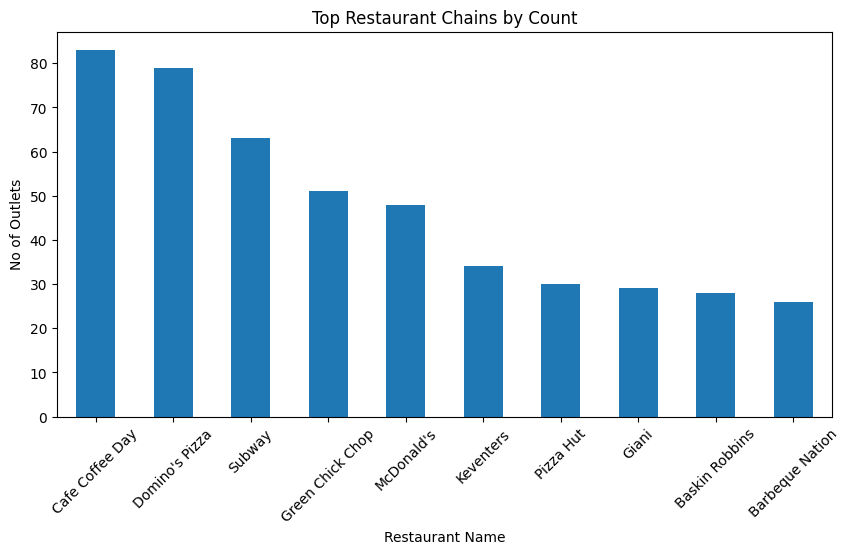

In [18]:
# Visualization
plt.figure(figsize=(10,5))
chains.head(10).plot(kind='bar')
plt.title("Top Restaurant Chains by Count")
plt.ylabel("No of Outlets")
plt.xticks(rotation=45)
plt.show()

## Insights

- Some restaurant chains dominate the dataset with multiple outlets.
- Popular chains tend to maintain consistent ratings.
- Chain restaurants benefit from brand recognition and customer trust.
- Highly rated chains often attract larger customer bases.

#  Final Conclusion
This project successfully analyzed restaurant data using Python libraries such as Pandas, Matplotlib, and Seaborn.

Key findings include:
- Identification of popular cuisines
- City-wise restaurant trends
- Relationship between ratings and delivery services
- Restaurant chain popularity analysis

This analysis demonstrates practical data cleaning, visualization, and exploratory data analysis skills.
